# Song Blob Visualisation
Renders colour blobs for a sample of songs using embedding-driven synthesis.

In [6]:
import json
import csv
import math
import numpy as np
import colorsys
from PIL import Image
from collections import defaultdict
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

DATA_DIR = "./data"
OUTPUT_DIR = "./outputs"
CSV_DIR  = f"{DATA_DIR}/csv"
EMB_DIR  = f"{DATA_DIR}/embeddings"

with open(f"{EMB_DIR}/genre_embeddings.json") as f: genre_raw = json.load(f)
with open(f"{EMB_DIR}/tag_embeddings.json")   as f: tag_raw   = json.load(f)

genres, tags         = list(genre_raw.keys()), list(tag_raw.keys())
genre2idx, tag2idx   = {g: i for i, g in enumerate(genres)}, {t: i for i, t in enumerate(tags)}

G = np.array(list(genre_raw.values()), dtype=np.float32)
T = np.array(list(tag_raw.values()),   dtype=np.float32)
G_norm = G / (np.linalg.norm(G, axis=1, keepdims=True) + 1e-9)
T_norm = T / (np.linalg.norm(T, axis=1, keepdims=True) + 1e-9)

print(f"genres: {len(genres)} (dim={G.shape[1]}) | tags: {len(tags)} (dim={T.shape[1]})")

genres: 1305 (dim=32) | tags: 985 (dim=64)


In [7]:
def read_csv(path):
    with open(path, encoding='utf-8', errors='replace') as f:
        reader = csv.reader(f, delimiter=';')
        headers = [h.strip().strip('"') for h in next(reader)[0].split(',')]
        return [dict(zip(headers, [p.strip().strip('"') for p in row]))
                for row in reader if len(row) == len(headers)]

song_lookup = {}
song_genres = defaultdict(set)
for row in read_csv(f"{CSV_DIR}/songs.csv"):
    sid = row['spotify_id']
    song_lookup[sid] = row
    if row['genre_name'] in genre2idx:
        song_genres[sid].add(row['genre_name'])

song_tags_full = defaultdict(dict)
for row in read_csv(f"{CSV_DIR}/tags.csv"):
    sid, tag = row['song_spotify_id'], row['tag'].lower().strip()
    pop = int(row['popularity']) if row['popularity'].isdigit() else 0
    if tag in tag2idx and pop > song_tags_full[sid].get(tag, 0):
        song_tags_full[sid][tag] = pop

song_tags = {sid: sorted(d.items(), key=lambda x: -x[1])[:8]
             for sid, d in song_tags_full.items()}

print(f"Loaded {len(song_lookup):,} songs")

Loaded 203,842 songs


In [8]:
pca_g_color  = PCA(n_components=3).fit(G_norm)
pca_t_color  = PCA(n_components=3).fit(T_norm)
pca_g_layout = PCA(n_components=2).fit(G_norm)
pca_t_layout = PCA(n_components=2).fit(T_norm)

GENRE_DIM = G.shape[1]
TAG_DIM   = T.shape[1]

COLOR_OVERRIDES = {
    "metal":[120,10,10],"death metal":[80,10,20],"black metal":[25,15,35],
    "thrash metal":[140,20,20],"doom metal":[50,20,40],"grindcore":[110,10,30],
    "hardcore":[160,20,20],"punk":[180,20,40],"grunge":[90,60,30],"emo":[70,30,60],
    "goth":[40,20,60],"industrial":[60,60,70],"darkwave":[50,30,80],
    "rap":[50,50,60],"hip hop":[70,60,90],"trap":[80,30,100],
    "folk":[140,180,70],"country":[200,140,60],"acoustic":[200,170,110],
    "blues":[40,80,180],"pop":[255,100,180],"dance pop":[255,80,200],
    "edm":[50,220,220],"house":[120,60,230],"tropical house":[255,200,80],
    "reggaeton":[255,80,60],"classical":[220,220,250],"ambient":[80,140,200],
    "chillout":[120,200,220],"jazz":[180,130,50],"soul":[180,80,40],
    "funk":[220,140,50],"r&b":[150,40,110],"rock":[180,60,60],
    "classic rock":[200,90,50],"shoegaze":[140,120,200],
    "melancholic":[60,80,140],"dark":[25,20,40],"happy":[255,220,80],
    "sad":[70,90,150],"chill":[120,200,220],"aggressive":[200,30,30],
    "energetic":[255,120,40],"romantic":[220,100,150],"atmospheric":[120,140,180],
    "upbeat":[255,180,80],"heavy":[50,40,50],"nostalgic":[180,140,100],
    "dreamy":[180,180,240],"epic":[80,50,130],
}
COLOR_OVERRIDES = {k: np.array(v, dtype=np.float32) for k, v in COLOR_OVERRIDES.items()}

def vec_to_rgb(vec, pca, temp=3.0, hue_offset=0.15):
    p = np.tanh(pca.transform(vec.reshape(1, -1))[0] * temp)
    h = (np.arctan2(p[1], p[0]) / (2 * np.pi) + 0.5 + hue_offset) % 1.0
    s = np.clip(np.sqrt(p[0]**2 + p[1]**2) * 0.5 + 0.5, 0.5, 1.0)
    v = np.clip((p[2] + 1) / 2, 0.2, 1.0)
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    return np.array([r * 255, g * 255, b * 255], dtype=np.float32)

def vec_to_xy(vec, pca, size, padding=0.18):
    p   = pca.transform(vec.reshape(1, -1))[0]
    p_t = np.tanh(p * 0.6)
    x   = (p_t[0] + 1) / 2 * size * (1 - 2 * padding) + size * padding
    y   = (p_t[1] + 1) / 2 * size * (1 - 2 * padding) + size * padding
    return float(x), float(y)

def get_genre_color(name):
    n = name.lower()
    if n in COLOR_OVERRIDES: return COLOR_OVERRIDES[n].copy()
    if n in genre2idx:       return vec_to_rgb(G_norm[genre2idx[n]], pca_g_color)
    return None

def get_tag_color(name):
    n = name.lower()
    if n in COLOR_OVERRIDES: return COLOR_OVERRIDES[n].copy()
    if n in tag2idx:         return vec_to_rgb(T_norm[tag2idx[n]], pca_t_color)
    return None

In [9]:
SIZE = 400

def song_to_vec(sid):
    g_set = song_genres.get(sid, set())
    if not g_set: return None
    g_mean = np.mean([G_norm[genre2idx[g]] for g in g_set if g in genre2idx], axis=0)
    tags = song_tags.get(sid, [])
    if tags: t_mean = np.mean([T_norm[tag2idx[t]] for t, _ in tags if t in tag2idx], axis=0)
    else:    t_mean = np.zeros(TAG_DIM, dtype=np.float32)
    return np.concatenate([g_mean, t_mean]).astype(np.float32)

def synthesize(song_vec, top_g=5, top_t=8):
    g_part = song_vec[:GENRE_DIM]
    t_part = song_vec[GENRE_DIM:]
    g_n    = g_part / (np.linalg.norm(g_part) + 1e-9)
    t_n    = t_part / (np.linalg.norm(t_part) + 1e-9)
    g_sims = G_norm @ g_n
    t_sims = T_norm @ t_n
    g_top  = np.argsort(g_sims)[::-1][:top_g]
    t_top  = np.argsort(t_sims)[::-1][:top_t]
    return ([(genres[i], float(g_sims[i])) for i in g_top],
            [(tags[i],   float(t_sims[i])) for i in t_top])

def render_blob(song_vec, size=SIZE):
    syn_genres, syn_tags = synthesize(song_vec)
    canvas = np.zeros((size, size, 3), dtype=np.float32)
    y_grid, x_grid = np.mgrid[0:size, 0:size]

    n_g, n_t   = len(syn_genres), len(syn_tags)
    genre_base = size * (0.20 + 0.10 / max(n_g, 1))
    tag_base   = size * (0.12 + 0.06 / max(n_t, 1))

    g_max = max((s for _, s in syn_genres), default=0) or 1.0
    for name, sim in syn_genres:
        color = get_genre_color(name)
        if color is None: continue
        x, y   = vec_to_xy(G_norm[genre2idx[name]], pca_g_layout, size, padding=0.22)
        weight = max(sim / g_max, 0.3)
        dist   = np.sqrt((x_grid - x)**2 + (y_grid - y)**2)
        mask   = np.clip(1 - dist / (genre_base * weight), 0, 1) ** 2
        canvas += color[None, None, :] * mask[..., None] * 0.04 * weight

    t_max = max((s for _, s in syn_tags), default=0) or 1.0
    for name, sim in syn_tags:
        color = get_tag_color(name)
        if color is None: continue
        x, y   = vec_to_xy(T_norm[tag2idx[name]], pca_t_layout, size, padding=0.15)
        weight = max(sim / t_max, 0.3)
        dist   = np.sqrt((x_grid - x)**2 + (y_grid - y)**2)
        mask   = np.clip(1 - dist / (tag_base * weight), 0, 1) ** 2
        canvas += color[None, None, :] * mask[..., None] * 0.04 * weight

    canvas = np.clip(canvas, 0, 1)
    # lightness cap to avoid over-saturation
    mx = canvas.max(-1); mn = canvas.min(-1)
    L  = (mx + mn) / 2
    scale  = np.where(L > 0, np.minimum(L, 0.78) / (L + 1e-9), 1.0)
    canvas = canvas * scale[..., None]
    canvas = np.power(canvas, 0.85)
    return (np.clip(canvas, 0, 1) * 255).astype(np.uint8), syn_genres, syn_tags

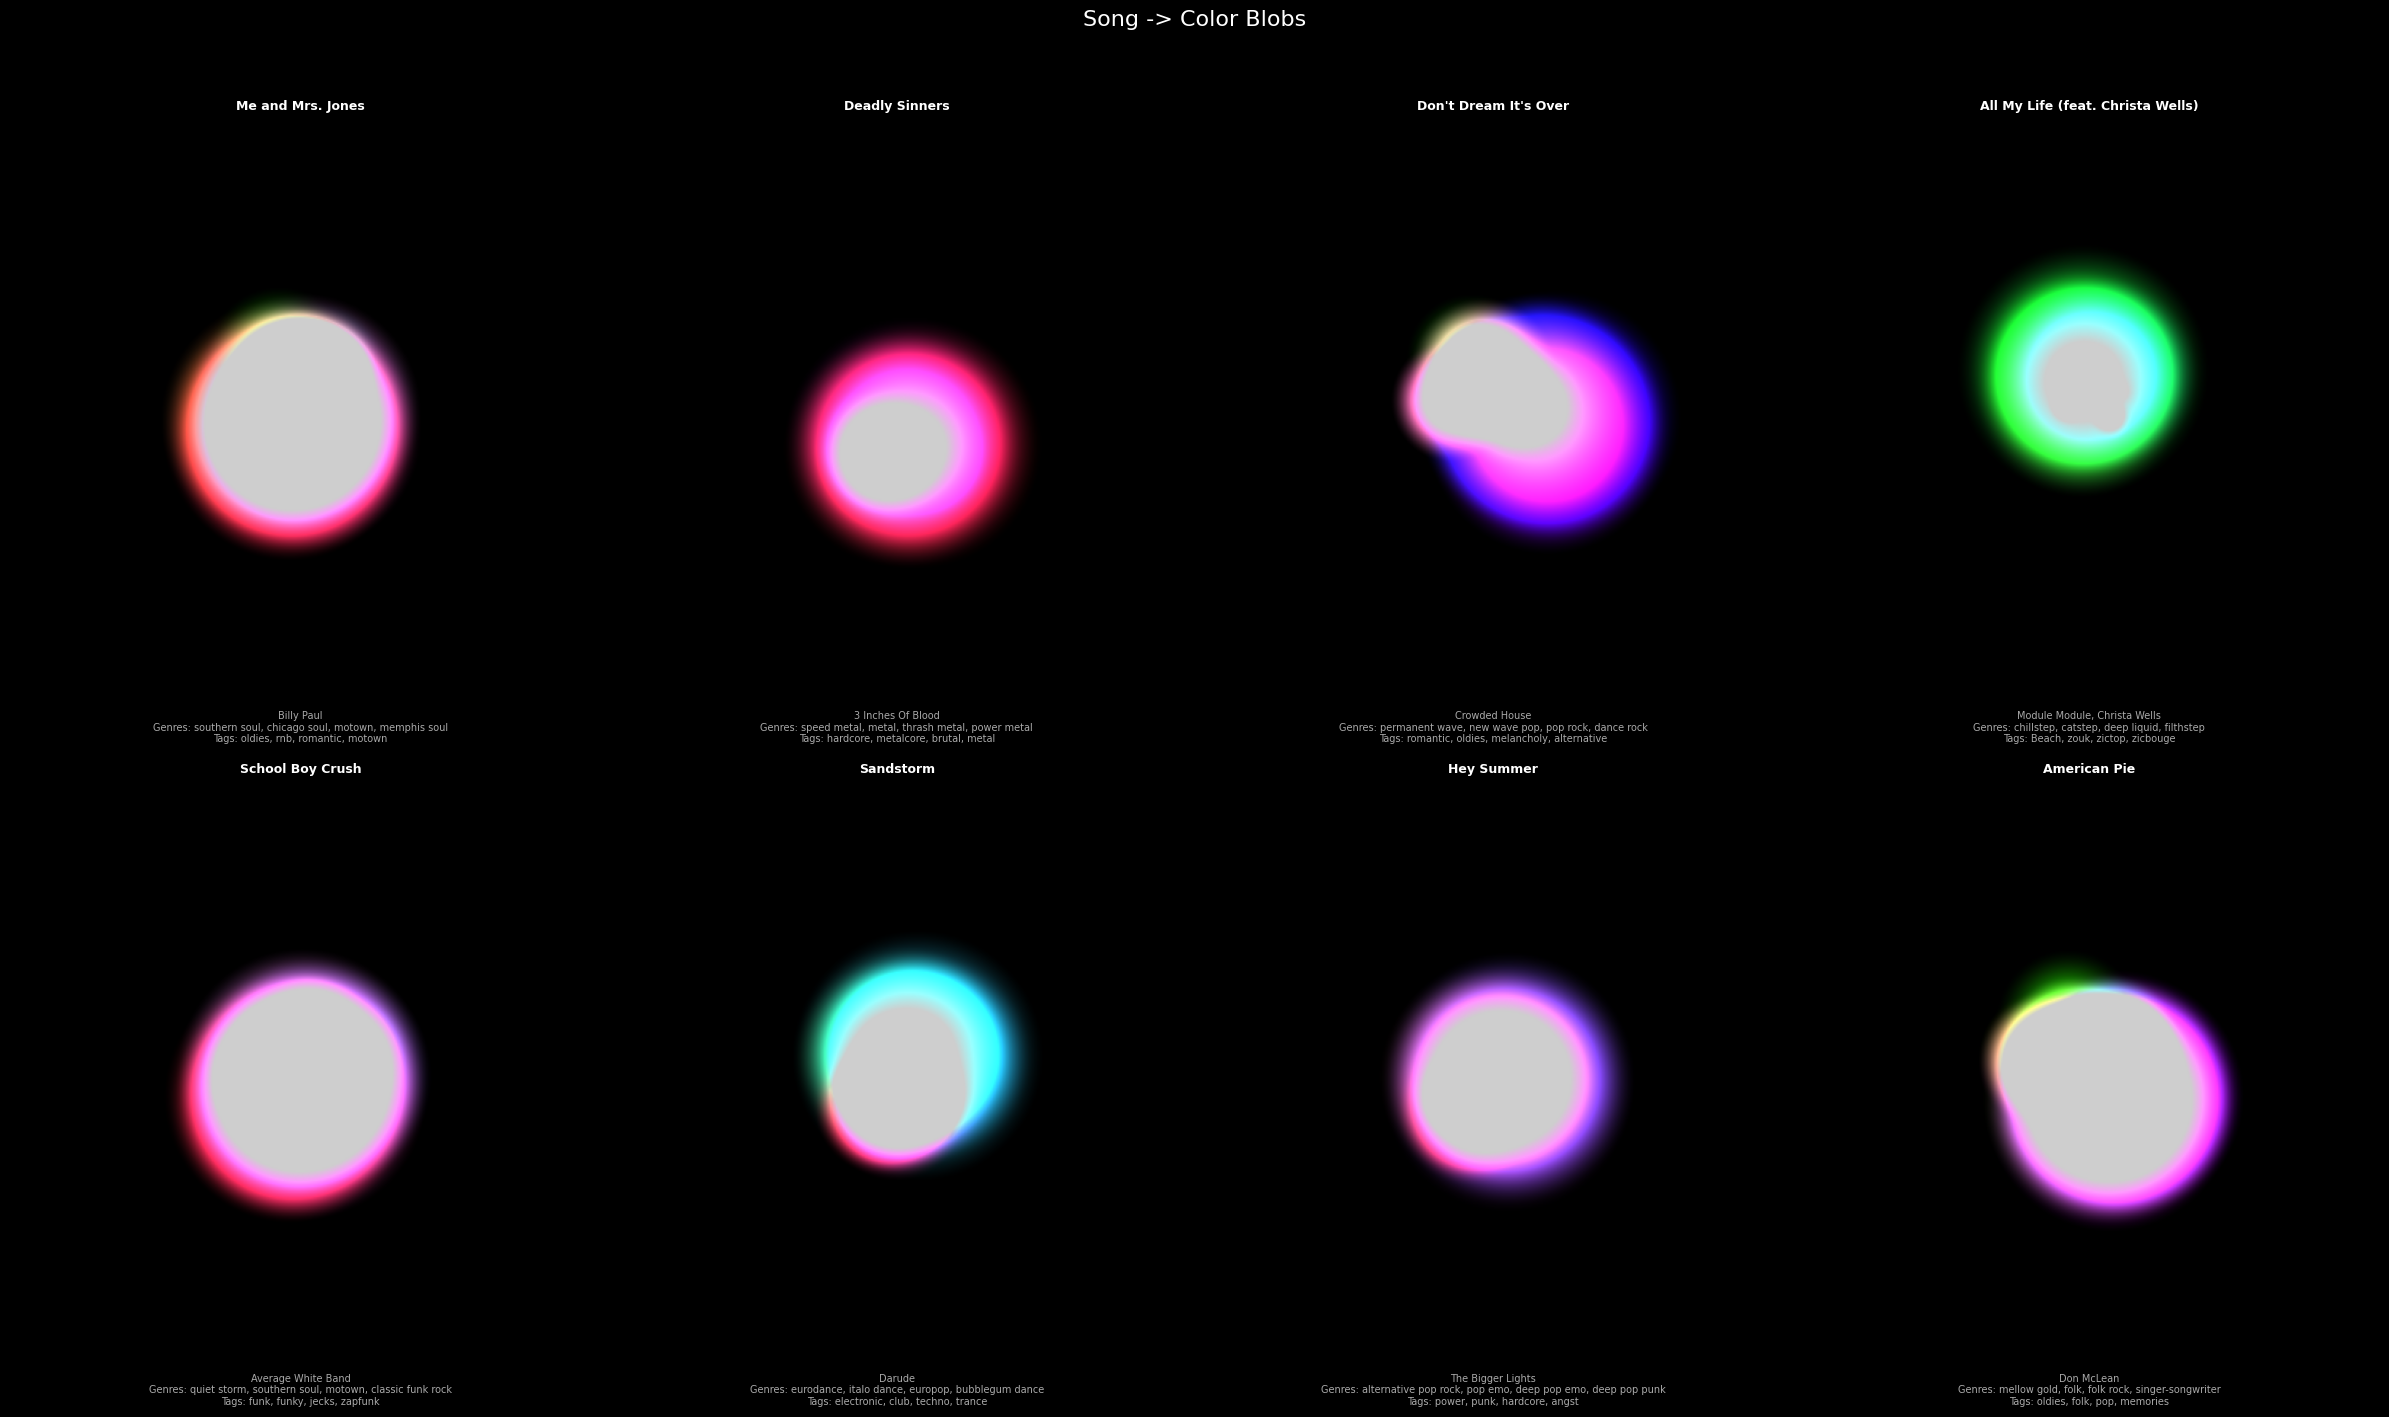

In [10]:
TEST_IDS = [
    "5GYcaVfaFBHe2gzA6Oybgj",
    "52mxPsGKbfyElOA0FCtc0l",
    "68wIBE5dVVX8RyfZCJnAj5",
    "4YP2nQliU8KsUB74XTP5aP",
    "0wNUTleNAhiAFPghCxLt27",
    "24CXuh2WNpgeSYUOvz14jk",
    "4ygIRtbrrMlL8fBBADwzEj",
    "2QgWuCtBpNIpl5trmKCxRf",
]

n_cols = 4
n_rows = math.ceil(len(TEST_IDS) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 7 * n_rows))
fig.patch.set_facecolor('#000000')
axes = axes.flatten()

for i, sid in enumerate(TEST_IDS):
    vec = song_to_vec(sid)
    if vec is None:
        axes[i].axis('off')
        continue

    img, syn_genres, syn_tags = render_blob(vec)
    row        = song_lookup.get(sid, {})
    genres_str = ', '.join(g for g, _ in syn_genres[:4])
    tags_str   = ', '.join(t for t, _ in syn_tags[:4])

    axes[i].imshow(img)
    axes[i].set_facecolor('#000000')
    axes[i].set_title(row.get('name', sid), color='white', fontsize=9, fontweight='bold', pad=6)
    axes[i].set_xlabel(
        f"{row.get('artist','')}\nGenres: {genres_str}\nTags: {tags_str}",
        color='#aaaaaa', fontsize=7, labelpad=8
    )
    axes[i].set_xticks([]); axes[i].set_yticks([])
    for spine in axes[i].spines.values(): spine.set_visible(False)

for j in range(len(TEST_IDS), len(axes)): axes[j].axis('off')

plt.suptitle("Song -> Color Blobs", fontsize=16, color='white', y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/multi_blobs.png", dpi=150, bbox_inches='tight', facecolor='#000000')
plt.show()